In [1]:
import numpy as np
import random
from functools import reduce
from itertools import chain, combinations, product, repeat
from scipy import linalg, sparse
import matplotlib.pyplot as plt
import os
from scipy.stats import unitary_group
import time 
import rcFun
import scipy.linalg as LA


In [2]:
# Gates:

Id2 = np.array([[1,0],[0,1]], dtype = 'complex128')
S_X = np.array([[0,1],[1,0]], dtype = 'complex128')
S_Y = np.array([[0,-1j],[1j,0]], dtype = 'complex128')
S_Z = np.array([[1,0],[0,-1]], dtype = 'complex128')

S_plus = (S_X+1j*S_Y)/2
S_minus = (S_X-1j*S_Y)/2

paulis = [Id2, S_X, S_Y, S_Z]/np.sqrt(2)
basis4by4=np.kron(paulis,paulis)

In [3]:
def inner(X,Y):
    if type(X)!=np.ndarray:
        X=X.toarray()
        Y=Y.toarray()
    prod=np.trace(X.T.conj()@Y)
    return prod
    
# uniform-U(4) matrices:
# checked that the eigenvalue distribution is uniform
def mkU(n):
    Un = (np.random.random([n,n]) + 1j* np.random.random([n,n]))/np.sqrt(2)
    q,r = linalg.qr(Un)
    #d = np.diag(r)
    #ph = d/abs(d)
    #q = q * ph * q   
    return q

"""eigVals=np.array([0])
for i in range(100):
    [evals,evecs]=linalg.eig(mkU(100))
    eigVals = np.concatenate([eigVals,evals])
plt.hist(np.arctan(np.real(eigVals[1:])/np.imag(eigVals[1:])),20)"""


def mkLiouvillian(rate, dt, ldbldOp, debug): 
    # Not sure how to include an environment qutrit and maintain unitarity

    L1 = np.kron(np.sqrt(rate/2) *ldbldOp, np.eye(2))
    L2 = np.kron(np.eye(2), np.sqrt(rate/2) *ldbldOp)
    
    h = -1j * linalg.logm(unitary_group.rvs(4)) #- (np.kron(ldbldOp, np.eye(2)) + np.kron(np.eye(2), ldbldOp))
    
    H =  (np.kron(h.conj(), np.eye(4)) - np.kron(np.eye(4), h) )
    
    #print(np.allclose(H, H.T.conj()))
    lindblads = [L1,L2]
    
    if debug == True: print(np.allclose(H, H.T.conj()) )    
    
    G = np.zeros([len(L1)**2,len(L1)**2], dtype = 'complex128')
    for L in lindblads:
        G += np.kron(L.conj(), L) - 1/2 * np.kron(np.eye(len(L)), L.T.conj()@L) - 1/2 * np.kron(L.T@L.conj(), np.eye(len(L)))
        
    if debug == True: print(np.allclose(G, G.T.conj()) )
        
    denseU=linalg.expm((-1j*H + G) * dt)
    
    if debug == True: 
        #print(denseU.T.conj()@denseU)
        
        print(np.allclose((-1j*H + G) * dt, ((-1j*H + G) * dt).T.conj() ) )
        print(np.allclose(denseU.T.conj()@denseU, np.eye(len(denseU)) ))
    
    return denseU

def mkKrausOps(U): 
    X = np.reshape(np.transpose(np.reshape(U,[4]*int(np.log2(len(U)))),[0,2,1,3]),list(U.shape))   
    [eigVals, eigVecs] = linalg.eigh(X)
    
    krausOps=[]
    
    for i in range(len(U)):
        if abs(eigVals[i])>1e-10:
            krausOps = krausOps + [ sparse.csr_matrix(np.sqrt(eigVals[i]) * np.reshape(eigVecs[:,i],[4,4]))]
            
    return krausOps

def flatten_tensor_op(operator):
    length = len(operator.shape)
    halflength = length//2
    reorder = np.transpose(operator,[2*n for n in range(0,halflength)]+[2*n+1 for n in range(0,halflength)])
    return np.reshape(reorder, (np.prod(operator.shape[::2]), np.prod(operator.shape[1::2])))

#only works for tensor products of 2-state systems
def unflatten_tensor_op(operator):
    halflength = int(np.log2(operator.shape[0]))
    reorder = np.reshape(operator, (2,)*(2*halflength))
    return np.transpose(reorder, [n//2+halflength*(n%2) for n in range(0,halflength*2)])

def Negativity(densitymatx, transpose_indices):
    unflatrho = unflatten_tensor_op(densitymatx)
    transposer = list(range(len(unflatrho.shape)))
    for i in transpose_indices:
        transposer[2*i+1],transposer[2*i] = transposer[2*i],transposer[2*i+1]
    transposed = flatten_tensor_op(np.transpose(unflatrho,tuple(transposer)))
    return (np.trace(LA.sqrtm(transposed.T.conj()@transposed))-1)/2



(array([11., 10., 10., 10.,  9.,  8., 12.,  9., 10., 11.]),
 array([-3.13347239, -2.50993512, -1.88639785, -1.26286058, -0.63932331,
        -0.01578604,  0.60775123,  1.2312885 ,  1.85482577,  2.47836304,
         3.10190031]),
 [<matplotlib.patches.Polygon at 0x7fde99d9e4d0>])

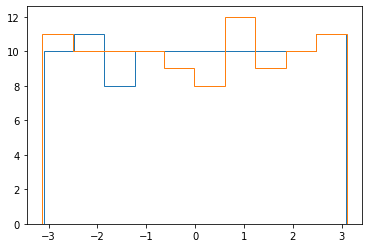

In [21]:
n = 100
H1 = -1j * linalg.logm(unitary_group.rvs(n))
H2 = -1j * linalg.logm(mkU(n))
#print(linalg.eigh(H1)[0])
#print(linalg.eigh(H2)[0])
plt.hist(linalg.eigh(H1)[0], histtype = 'step')
plt.hist(linalg.eigh(H2)[0], histtype = 'step')

In [30]:
KList = mkKrausOps(mkLiouvillian(rate=0.1, dt=5, ldbldOp=S_minus, debug = True))
Ksum = np.zeros([4,4])
for k in KList:   
    Ksum += k.T.conj() @ k

True
False
False
False


In [13]:
Ksum.round(3)

matrix([[ 1.+0.j, -0.-0.j,  0.+0.j, -0.+0.j],
        [-0.+0.j,  1.+0.j, -0.-0.j, -0.+0.j],
        [ 0.-0.j, -0.+0.j,  1.+0.j, -0.+0.j],
        [-0.-0.j, -0.-0.j, -0.-0.j,  1.+0.j]])

In [4]:
def decompKrausOps(krausOps):
    # for each kraus operator, there is a set of k_abs that
    # stores the inner product of each on-site kraus ops with the basis in a row
    
    k_abs=np.array([[] for i in range(16)],dtype='complex128').T
    for (k,op) in enumerate(krausOps):
        k_temp = np.zeros(len(basis4by4),dtype='complex128')
        for (i,b) in enumerate(basis4by4):
            k_temp[i] = inner(b, op)
        k_abs = np.vstack([k_abs,k_temp])
        
    return k_abs


def mkGlobalKrausOps(layer, Nqubit, rate, dt, ldbldOp, debug=True):
    
    allKs = {}

    if np.mod(layer,2) == 0:    
        # position records the site with the non-trivial unitary
        
        positions = [i for i in range(0, Nqubit-1, 2)]
        
        for pos in positions:
            
            # one needs to make N/2 different random unitaries        
            krausOps = mkKrausOps(mkLiouvillian(rate, dt, ldbldOp, debug))
            allKs[pos] = []

            for i in range(len(krausOps)):
                U_chain = chain(repeat(np.eye(4), pos//2), [krausOps[i]], repeat(np.eye(4), Nqubit//2 - pos//2 - 1))
                allKs[pos] += [reduce(sparse.kron, U_chain)]

    else:
        positions = list(range(1,Nqubit,2))
        
        for pos in positions:  
            krausOps = mkKrausOps(mkLiouvillian(rate, dt, ldbldOp, debug))
            allKs[pos] = []
            
            if pos < Nqubit-1:

                for i in range(len(krausOps)):
                    U_chain = chain([np.eye(2)], repeat(np.eye(4), pos//2), [krausOps[i]], repeat(np.eye(4), Nqubit//2 - pos//2 - 2), [np.eye(2)])
                    allKs[pos] += [reduce(sparse.kron, U_chain)]
                    
            else:
                # decomposition of Kraus is required with PBC
                
                k_abs = decompKrausOps(krausOps)
                
                for row in k_abs:

                    K_jk = sparse.csr_matrix(np.zeros([2**Nqubit,2**Nqubit], dtype='complex128') )

                    for (basisInd, whichPauli) in enumerate(row):  
                        U_chain = np.array([np.eye(2)] * Nqubit,dtype='complex128') 
                        U_chain[pos] = paulis[basisInd//4] 
                        U_chain[np.mod(pos+1,Nqubit)] = paulis[np.mod(basisInd,4)] 

                        K_jk +=  row[basisInd] * reduce(sparse.kron, chain(U_chain))

                    allKs[pos] = allKs[pos] + [K_jk]   

    return allKs


In [91]:
# check if all the Kraus operators sum to 1

for s in range(N): 
    purities[s]=calcPurity(rho.toarray())
    trace[s]=np.trace(rho.toarray())
    
    allKrausOps = mkGlobalKrausOps(layer=s, Nqubit=2, rate=20, dt=5, ldbldOp=S_minus, debug=False)
    # ok the trace is not 1
    rho = evolveKrausU(s, allKrausOps, rho)
 
    Ksum = np.zeros([16,16])
    for k in allKs.keys(): 
        Ksum = np.zeros([16,16])
        for mat in allKs[k]:
            Ksum += mat.T.conj() @ mat
            
        #print(np.allclose(Ksum, np.eye(16)))


/Users/cathy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:4: ComplexWarning: Casting complex values to real discards the imaginary part
  after removing the cwd from sys.path.
/Users/cathy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:5: ComplexWarning: Casting complex values to real discards the imaginary part
  """


True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


In [139]:
np.linalg.eig(S_minus)

(array([0.+0.j, 0.+0.j]),
 array([[ 0.00000000e+000+0.j, -2.00416836e-292-0.j],
        [ 1.00000000e+000+0.j,  1.00000000e+000+0.j]]))

In [118]:
# employ the faster Kraus Unitary sum
def evolveKrausU(allKs, rho, debug = True):
    
    Nqubit = int(np.log2(len(rho.toarray())))
 
    newRho = rho
    for key in allKs.keys():
        rho = newRho
        newRho = sparse.csr_matrix(np.zeros([2**Nqubit,2**Nqubit]) )

        for mat in allKs[key]:
            newRho += mat @ rho @ mat.T.conj()   
            
            if debug == True:
                print(np.trace(newRho.toarray()))
        
    return newRho


In [7]:
def ptrace_rho(operator, elements):    

    halflength = int(np.log2(operator.shape[0]))
    reorder = np.reshape(operator, (2,)*(2*halflength))
    rho = np.transpose(reorder, [n//2+halflength*(n%2) for n in range(0,halflength*2)])

    elems = set(elements)
    counter = 0
    indexarr = []
    for i in range(len(rho.shape)//2):
        if i in elems:
            indexarr += [counter,counter]
            counter += 1
        else:
            indexarr += [counter,counter+1]
            counter += 2
            
    operator= np.einsum(rho, indexarr)
    length = len(operator.shape)
    halflength = length//2
    reorder = np.transpose(operator,[2*n for n in range(0,halflength)]+[2*n+1 for n in range(0,halflength)])
    
    return np.reshape(reorder, (np.prod(operator.shape[::2]), np.prod(operator.shape[1::2])))


def calcS(densityM, Ntot,partiesToTraceOut=[1]):
    redRho = partial_trace(densityM, partiesToTraceOut, [2]* Ntot)
    eVals = np.linalg.eigvalsh(redRho)
    eVals = eVals[np.where(eVals>1e-12)]
    S = -sum(eVals*np.log2(eVals))
    return S

def calcPurity(densityM):
    purity = np.trace(densityM@densityM)
    return purity
    

In [5]:
import seaborn as sbn
sbn.set(context='paper', font_scale=0.8, color_codes=True, palette='deep',style='ticks',
        rc={'mathtext.fontset': 'cm', 'axes.linewidth': 1, 'figure.dpi':300, 'figure.figsize':(2,1.5)})

In [4]:
# Now check msm probabilities

qb={}
qb[0]=np.array([1,0],dtype='complex128')
qb[1]=np.array([0,1],dtype='complex128')

Nqubit = 6
# pure state start
state0 = (qb[0] + qb[1])/np.sqrt(2)
state0rho = np.outer(state0, state0)
rho = sparse.csr_matrix(reduce(sparse.kron, [state0rho]*Nqubit))


In [86]:
rho = sparse.csr_matrix(reduce(sparse.kron, [state0rho]*Nqubit))

N=100
purities = np.zeros(N)
trace = np.zeros(N)
populations = np.zeros([1,4])

for s in range(N): 
    purities[s]=rcFun.calcPurity(rho.toarray())    
    
    # OK this the KrausOps can be computed outside of the loop, which gives one 2 sets of Kraus ops
    allKrausOps = rcFun.mkGlobalKrausOps(layer=s, Nqubit=2, rate=1, dt=5, ldbldOp=S_minus, debug=False)
    # ok the trace is not 1
    
    # Then the based on which layer, the evolve Kraus pick one of the 2 sets
    rho = rcFun.evolveKrausU(allKrausOps, rho, debug = False)

    populations = np.vstack([populations,np.linalg.eigh(rho.toarray())[0]])


/Users/cathy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:9: ComplexWarning: Casting complex values to real discards the imaginary part
  if __name__ == '__main__':
/Users/cathy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:10: ComplexWarning: Casting complex values to real discards the imaginary part
  # Remove the CWD from sys.path while we load stuff.


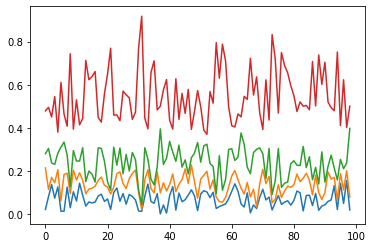

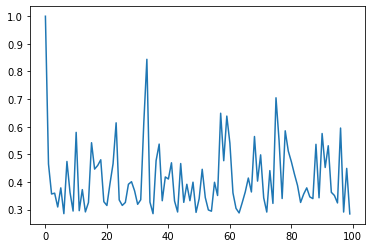

In [88]:
populations = populations[1:,:]

plt.plot(populations[:,0])
plt.plot(populations[:,1])
plt.plot(populations[:,2])
plt.plot(populations[:,3])

plt.figure()
plt.plot(purities)


In [7]:
rateList = np.logspace(-3,3,7)
N=100
purities = np.zeros([len(rateList),N])

for [ind,r] in enumerate(rateList):
    rho = sparse.csr_matrix(reduce(sparse.kron, [state0rho]*Nqubit))
    for s in range(N): 
        purities[ind,s]=rcFun.calcPurity(rho.toarray())

        # OK this the KrausOps can be computed outside of the loop, which gives one 2 sets of Kraus ops
        allKrausOps = rcFun.mkGlobalKrausOps(layer=s, Nqubit=Nqubit, rate=r, dt=5, ldbldOp=S_minus, debug=False)
        # ok the trace is not 1

        # Then the based on which layer, the evolve Kraus pick one of the 2 sets
        rho = rcFun.evolveKrausU(allKrausOps, rho, debug = False)



/Users/cathy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:8: ComplexWarning: Casting complex values to real discards the imaginary part
  


KeyboardInterrupt: 

In [122]:
import scipy
def monoExp(x, m, t, b):
    return m * np.exp(-t * x) + b


0.9967058472945692 0.014669949272955438 0.008293095061426113


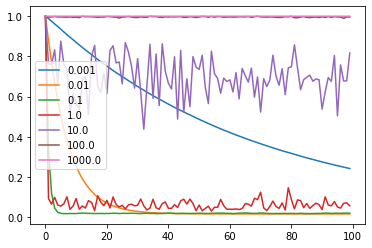

In [124]:
for j in range(7):
    plt.plot(purities[j,:])
    
plt.legend(rateList)

In [5]:
rateList = np.logspace(-3,3,7)
N=200
purities = np.zeros([len(rateList),N])
negativities = np.zeros([len(rateList),N])
Nqubit=6

for [ind,r] in enumerate(rateList):
    rho = sparse.csr_matrix(reduce(sparse.kron, [state0rho]*Nqubit))
    for s in range(N): 
        purities[ind,s]=rcFun.calcPurity(rho.toarray())
        negativities[ind,s]=rcFun.calcNegativity(rho.toarray(),[n for n in range(Nqubit//2)])

        # OK this the KrausOps can be computed outside of the loop, which gives one 2 sets of Kraus ops
        allKrausOps = rcFun.mkGlobalKrausOps(layer=s, Nqubit=Nqubit, rate=r, dt=5, ldbldOp=S_minus, debug=False)
        # ok the trace is not 1

        # Then the based on which layer, the evolve Kraus pick one of the 2 sets
        rho = rcFun.evolveKrausU(allKrausOps, rho, debug = False)



/Users/cathy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:10: ComplexWarning: Casting complex values to real discards the imaginary part
  # Remove the CWD from sys.path while we load stuff.
/Users/cathy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:11: ComplexWarning: Casting complex values to real discards the imaginary part
  # This is added back by InteractiveShellApp.init_path()


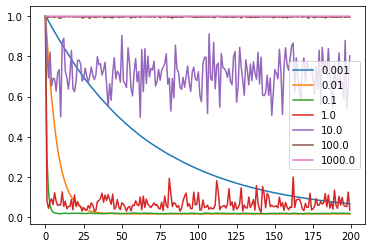

In [7]:
for j in range(7):
    plt.plot(purities[j,:])
    #p0 = (1, .1, 0.25) # start with values near those we expect
    #params, cv = scipy.optimize.curve_fit(monoExp, np.arange(100), purities[j,:], p0)
    #m, t, b = params
    #print(m,t,b)
    
plt.legend(rateList)

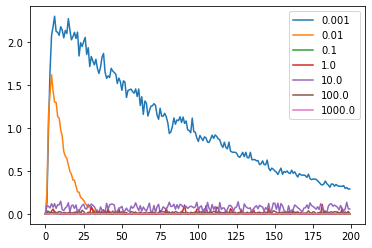

In [8]:
for j in range(7):
    plt.plot(negativities[j,:])
    
plt.legend(rateList)

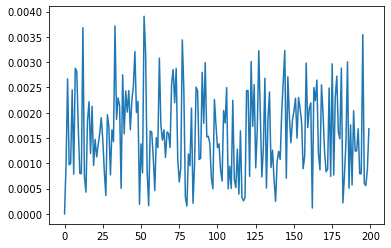

In [14]:
plt.plot(negativities[6,:])


In [105]:
N=1000
purities1000 = np.zeros(N)
Nqubit=2
r=0.001

rho = sparse.csr_matrix(reduce(sparse.kron, [state0rho]*Nqubit))
for s in range(N): 
    purities1000[s]=rcFun.calcPurity(rho.toarray())

    # OK this the KrausOps can be computed outside of the loop, which gives one 2 sets of Kraus ops
    allKrausOps = rcFun.mkGlobalKrausOps(layer=s, Nqubit=Nqubit, rate=r, dt=5, ldbldOp=S_minus, debug=False)
    # ok the trace is not 1

    # Then the based on which layer, the evolve Kraus pick one of the 2 sets
    rho = rcFun.evolveKrausU(allKrausOps, rho, debug = False)


/Users/cathy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:8: ComplexWarning: Casting complex values to real discards the imaginary part
  


0.7518016543899716 186.96620213230275 0.24964206318712445


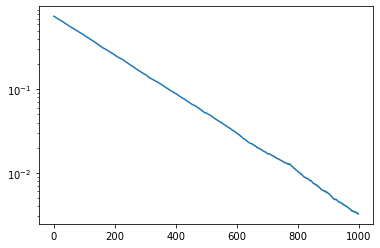

In [129]:
plt.semilogy(purities1000-0.25)
p0 = (1, .1, 0.25) # start with values near those we expect
params, cv = scipy.optimize.curve_fit(monoExp, np.arange(1000), purities1000, p0)

m, t, b = params
print(m,1/t,b)


In [33]:
def mkLindbladian(rate, dt, ldbldOp, debug): 
    # Not sure how to include an environment qutrit and maintain unitarity

    L1 = np.kron(np.sqrt(rate/2) *ldbldOp, np.eye(2))
    L2 = np.kron(np.eye(2), np.sqrt(rate/2) *ldbldOp)
    
    h = -1j * linalg.logm(unitary_group.rvs(4)) #- (np.kron(ldbldOp, np.eye(2)) + np.kron(np.eye(2), ldbldOp))
    
    H =  (np.kron(h.conj(), np.eye(4)) - np.kron(np.eye(4), h) )
    
    #print(np.allclose(H, H.T.conj()))
    lindblads = [L1,L2]
    
    if debug == True: print(np.allclose(H, H.T.conj()) )    
    
    G = np.zeros([len(L1)**2,len(L1)**2], dtype = 'complex128')
    for L in lindblads:
        G += np.kron(L.conj(), L) - 1/2 * np.kron(np.eye(len(L)), L.T.conj()@L) - 1/2 * np.kron(L.T@L.conj(), np.eye(len(L)))
      
    lindbladian = (-1j*H + G) * dt

    return lindbladian # to act on the vectorized density matrix of 2 qubits

[-99.0464-0.j     -75.6026-0.j     -75.2001-0.9961j -75.2001+0.9961j
 -74.4309+0.j     -50.2373+0.j     -50.2315-1.0836j -50.2315+1.0836j
 -49.7565-0.j     -49.7442-1.0427j -49.7442+1.0427j -25.1845-1.5576j
 -25.1845+1.5576j -25.1028-0.3867j -25.1028+0.3867j  -0.    -0.j    ]


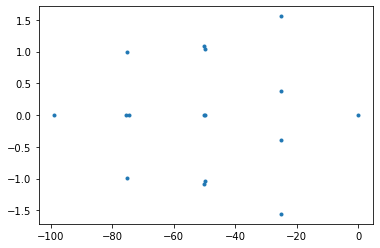

In [82]:
LiouMat_minus=mkLindbladian(rate=100, dt=1, ldbldOp=S_minus, debug=False)
[eVals, eVecs]=linalg.eig(LiouMat_minus)
print(np.sort(eVals.round(4)))
plt.plot(eVals.real, eVals.imag,'.')

[-1.999533e+02-1.3425j -1.999533e+02+1.3425j -1.999472e+02-2.3122j
 -1.999472e+02+2.3122j -1.000088e+02-1.9826j -1.000088e+02+1.9826j
 -1.000073e+02-3.2932j -1.000073e+02+3.2932j -1.000008e+02-1.2243j
 -1.000008e+02+1.2243j -9.998310e+01-0.0808j -9.998310e+01+0.0808j
 -9.910000e-02-0.j     -5.940000e-02+0.j     -4.030000e-02+0.j
  0.000000e+00-0.j    ]


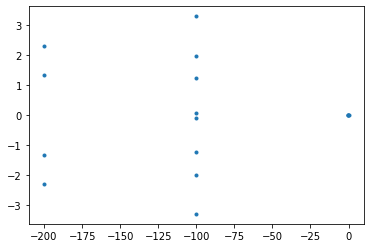

In [79]:
LiouMat_z=mkLindbladian(rate=100, dt=1, ldbldOp=S_Z, debug=False)
[eVals, eVecs]=linalg.eig(LiouMat_z)
print(np.sort(eVals.round(4)))
plt.plot(eVals.real, eVals.imag,'.')

In [52]:
plt.plot(trace)
plt.plot(purities)

NameError: name 'trace' is not defined

In [53]:
populations = populations[1:,:]

plt.plot(populations[:,0])
plt.plot(populations[:,1])
plt.plot(populations[:,2])
plt.plot(populations[:,3])


NameError: name 'populations' is not defined

In [14]:
# Now check msm probabilities

qb={}
qb[0]=np.array([1,0],dtype='complex128')
qb[1]=np.array([0,1],dtype='complex128')

Nqubit = 8

# pure state start
state0 = (qb[0] + qb[1])/np.sqrt(2)
state0rho = np.outer(state0, state0)
rho = sparse.csr_matrix(reduce(sparse.kron, [state0rho]*Nqubit))

t_total = 300
probMsm = 0
dt=5
steps = int(t_total/dt)
rep = 20

## exponential scale is too violent
#rateList = np.exp(-np.array([0, 0.1, 0.2, 0.3])*dt)
rateList = np.logspace(-5,3,9)

ensembleS_r = {}
ensembleP_r = {}

for rate in rateList:
    
    ensembleS_r[rate] = np.zeros([rep,steps])
    ensembleP_r[rate] = np.zeros([rep,steps])

    startTime = time.time()
    
    for e in range(rep):
        rho = sparse.csr_matrix(reduce(sparse.kron, [state0rho]*Nqubit))
        SList = np.zeros(steps)
        PList = np.zeros(steps)

        for s in range(steps):
            
            allKrausOps = rcFun.mkGlobalKrausOps(s, Nqubit, rate, dt, ldbldOp=S_minus, debug=False)
            rho = rcFun.evolveKrausU(allKrausOps, rho, False)
            #rho = mkS_zMsm(probMsm, rho)

            SList[s] = rcFun.calcS(rho.toarray(), partiesToTraceOut=list(range(0,Nqubit//2-1)))
            PList[s] = rcFun.calcPurity(rho.toarray())

            ensembleS_r[rate][e,s] = SList[s]
            ensembleP_r[rate][e,s] = PList[s]

    print(time.time()-startTime)


/Users/cathy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:46: ComplexWarning: Casting complex values to real discards the imaginary part


837.7677619457245
876.443076133728
876.4933331012726
876.6995389461517
942.1834750175476
1018.2141642570496
914.7409679889679
951.6385161876678
667.4374558925629


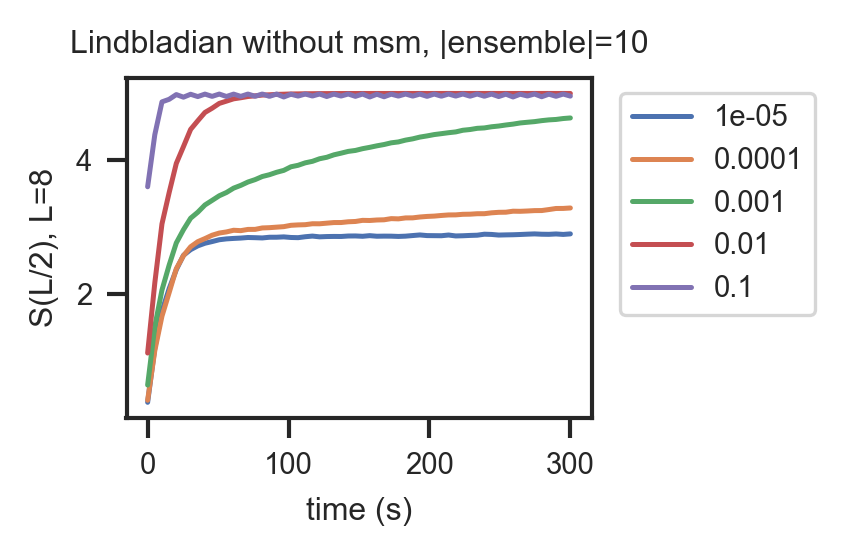

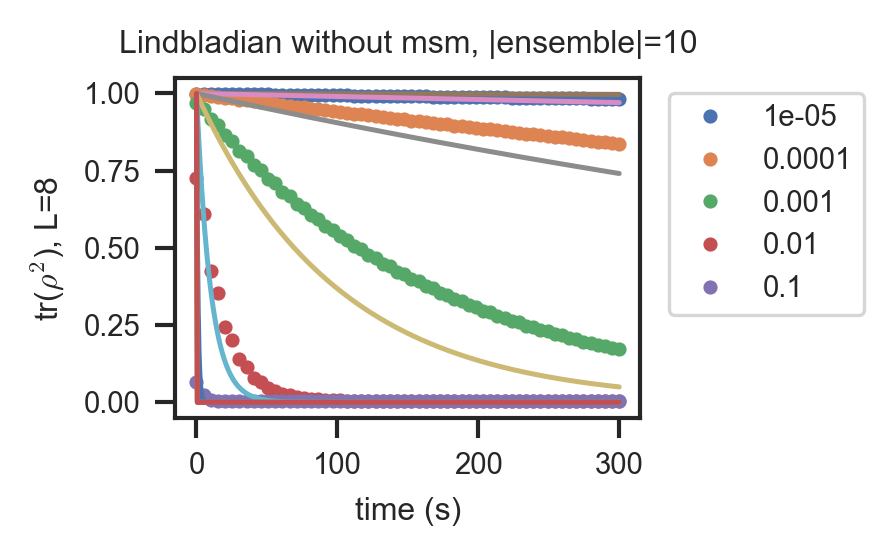

In [32]:
plt.figure()
t_total = 300
duration = np.linspace(0,t_total,int(t_total/dt))

for (j,rate) in enumerate(rateList[:5]):
    plt.plot(duration, np.average(ensembleS_r[rate] ,axis=0) )
plt.xlabel('time (s)')
plt.ylabel('S(L/2), L=8')
plt.title('Lindbladian without msm, |ensemble|=10')
plt.legend(rateList[:5], bbox_to_anchor= (1.03, 1) )


plt.figure()
for (j,rate) in enumerate(rateList[:5]):
    plt.plot(duration, np.average(ensembleP_r[rate] ,axis=0),'.' )
plt.xlabel('time (s)')
plt.ylabel(r'tr($\rho^2$), L=8')
plt.title('Lindbladian without msm, |ensemble|=10')
plt.legend(rateList[:5], bbox_to_anchor= (1.03, 1) )
for (j,rate) in enumerate(rateList):
    domain = np.linspace(0,t_total,500)
    plt.plot(domain, np.exp(-domain*rate) )




In [ ]:
plt.plot(duration, np.average(ensembleP_r[rate] ,axis=0),'.' )


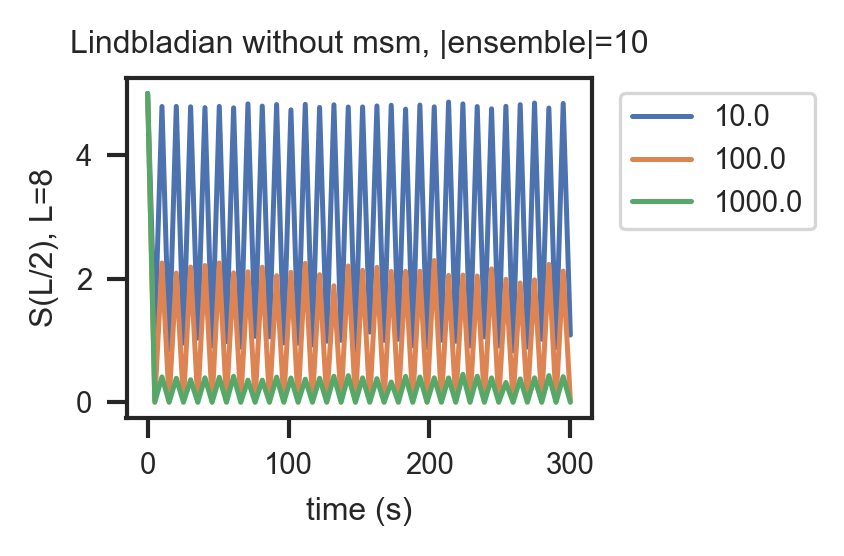

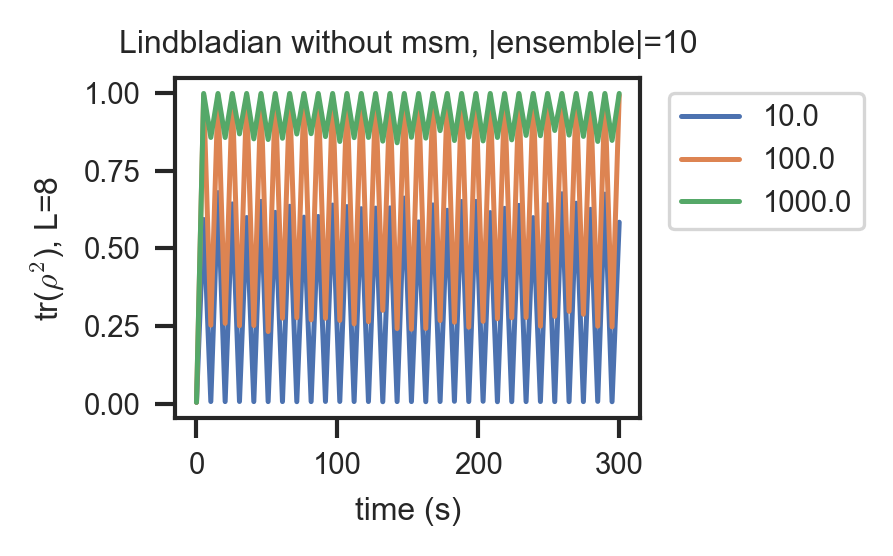

In [30]:
plt.figure()
t_total = 300
duration = np.linspace(0,t_total,int(t_total/dt))

for (j,rate) in enumerate(rateList[6:]):
    plt.plot(duration, np.average(ensembleS_r[rate] ,axis=0) )
plt.xlabel('time (s)')
plt.ylabel('S(L/2), L=8')
plt.title('Lindbladian without msm, |ensemble|=10')
plt.legend(rateList[6:], bbox_to_anchor= (1.03, 1) )


plt.figure()
for (j,rate) in enumerate(rateList[6:]):
    plt.plot(duration, np.average(ensembleP_r[rate] ,axis=0) )
plt.xlabel('time (s)')
plt.ylabel(r'tr($\rho^2$), L=8')
plt.title('Lindbladian without msm, |ensemble|=10')
plt.legend(rateList[6:], bbox_to_anchor= (1.03, 1) )



Text(0.5, 1.0, 'purity vs $\\Gamma$, no msm')

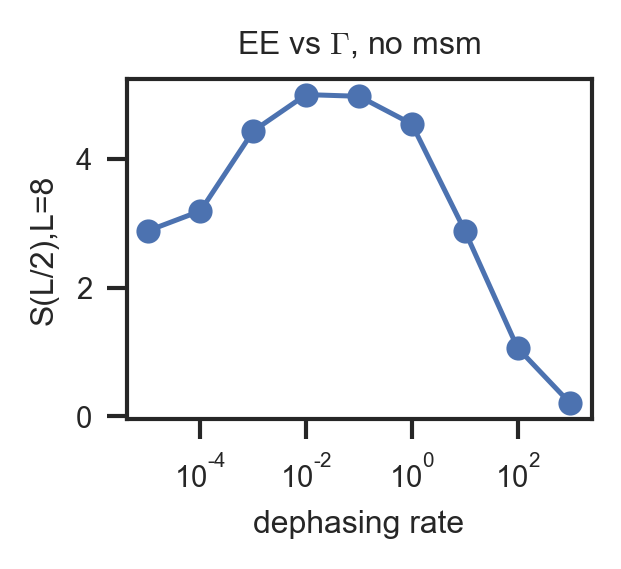

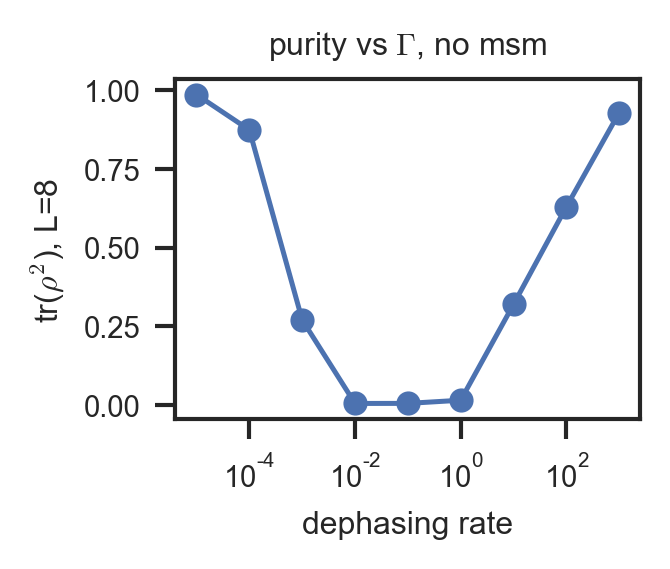

In [31]:
# entanglement entropy vs msm rate (before the state reaches the steady state)
avgS_dephase = [np.average(np.average(ensembleS_r[rate] ,axis=0)[30:]) for rate in rateList]

plt.figure()
plt.semilogx(np.array(rateList).astype(float), np.array(avgS_dephase).astype(float),'o-')
plt.xlabel('dephasing rate')
plt.ylabel('S(L/2),L=8')
plt.title(r'EE vs $\Gamma$, no msm')


# purity vs msm rate
avgP_dephase = [np.average(np.average(ensembleP_r[rate] ,axis=0)[30:]) for rate in rateList]

plt.figure()
plt.semilogx(np.array(rateList).astype(float), np.array(avgP_dephase).astype(float),'o-')
plt.xlabel('dephasing rate')
plt.ylabel(r'tr($\rho^2$), L=8')
plt.title(r'purity vs $\Gamma$, no msm')



In [145]:
# Now check msm probabilities

qb={}
qb[0]=np.array([1,0],dtype='complex128')
qb[1]=np.array([0,1],dtype='complex128')

Nqubit = 8
# mixed state start
state0rho = (np.outer(qb[0],qb[0]) + np.outer(qb[1],qb[1]))/2
rho = sparse.csr_matrix(reduce(sparse.kron, [state0rho]*Nqubit))

t_total = 200
probMsm = 0
dt=5
steps = int(t_total/dt)
rep = 10

rateList = np.logspace(-5,1,7)

ensembleS_r_mixed = {}
ensembleP_r_mixed = {}

for rate in rateList:
    
    ensembleS_r_mixed[rate] = np.zeros([rep,steps])
    ensembleP_r_mixed[rate] = np.zeros([rep,steps])

    startTime = time.time()
    
    for e in range(rep):
        rho = sparse.csr_matrix(reduce(sparse.kron, [state0rho]*Nqubit))
        SList = np.zeros(steps)
        PList = np.zeros(steps)

        for s in range(steps):
            
            allKrausOps = mkGlobalKrausOps(s, Nqubit, rate, dt, ldbldOp=S_minus, debug=False)
            rho = evolveKrausU(allKrausOps, rho, False)
            #rho = mkS_zMsm(probMsm, rho)

            SList[s] = calcS(rho.toarray(), Nqubit, partiesToTraceOut=list(range(1,Nqubit//2)))
            PList[s] = calcPurity(rho.toarray())

            ensembleS_r_mixed[rate][e,s] = SList[s]
            ensembleP_r_mixed[rate][e,s] = PList[s]


    print(time.time()-startTime)


/Users/cathy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:42: ComplexWarning: Casting complex values to real discards the imaginary part


362.33060479164124
395.6369798183441
383.5102961063385
401.02676606178284
395.585547208786
395.5297420024872
398.2463698387146


Text(0, 0.5, 'tr($\\rho^2$), L=8')

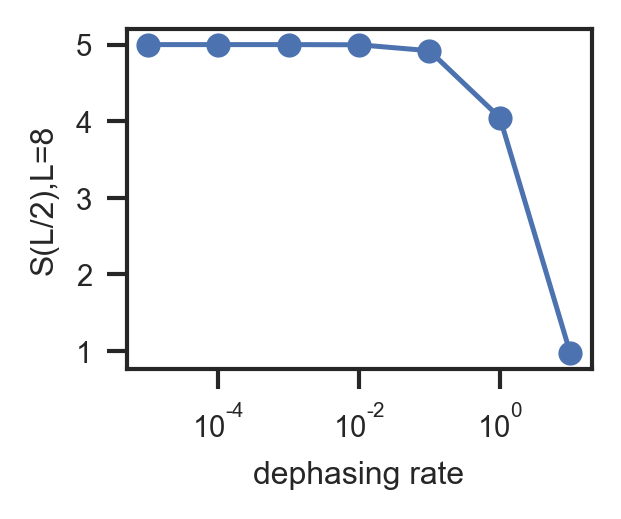

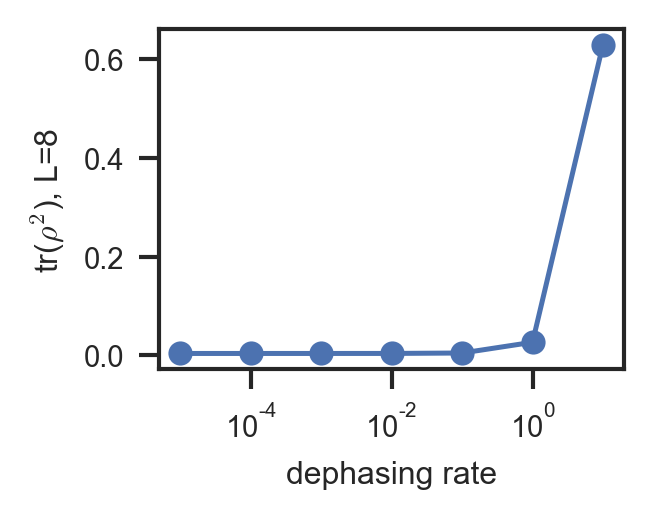

In [146]:
# entanglement entropy vs msm rate
avgS_dephase_mixed = [np.average(np.average(ensembleS_r_mixed[rate] ,axis=0)[30:]) for rate in rateList]

plt.figure()
plt.semilogx(np.array(rateList).astype(float), np.array(avgS_dephase_mixed).astype(float),'o-')
plt.xlabel('dephasing rate')
plt.ylabel('S(L/2),L=8')

# purity vs msm rate
avgP_dephase_mixed = [np.average(np.average(ensembleP_r_mixed[rate] ,axis=0)[30:]) for rate in rateList]

plt.figure()
plt.semilogx(np.array(rateList).astype(float), np.array(avgP_dephase_mixed).astype(float),'o-')
plt.xlabel('dephasing rate')
plt.ylabel(r'tr($\rho^2$), L=8')


In [ ]:
# Now check msm probabilities

qb={}
qb[0]=np.array([1,0],dtype='complex128')
qb[1]=np.array([0,1],dtype='complex128')

Nqubit = 8

# pure state start
state0 = (qb[0] + qb[1])/np.sqrt(2)
state0rho = np.outer(state0, state0)
rho = sparse.csr_matrix(reduce(sparse.kron, [state0rho]*Nqubit))

t_total = 300
probMsm = 0
dt=5
steps = int(t_total/dt)
rep = 20

## exponential scale is too violent
#rateList = np.exp(-np.array([0, 0.1, 0.2, 0.3])*dt)
rateList = np.logspace(-5,3,9)

ensembleS_r = {}
ensembleP_r = {}

for rate in rateList:
    
    ensembleS_r[rate] = np.zeros([rep,steps])
    ensembleP_r[rate] = np.zeros([rep,steps])

    startTime = time.time()
    
    for e in range(rep):
        rho = sparse.csr_matrix(reduce(sparse.kron, [state0rho]*Nqubit))
        SList = np.zeros(steps)
        PList = np.zeros(steps)

        for s in range(steps):
            
            allKrausOps = mkGlobalKrausOps(s, Nqubit, rate, dt, ldbldOp=S_minus, debug=False)
            rho = evolveKrausU(allKrausOps, rho, False)
            #rho = mkS_zMsm(probMsm, rho)

            SList[s] = calcS(rho.toarray(), Nqubit, partiesToTraceOut=list(range(1,Nqubit//2)))
            PList[s] = calcPurity(rho.toarray())

            ensembleS_r[rate][e,s] = SList[s]
            ensembleP_r[rate][e,s] = PList[s]


    print(time.time()-startTime)


In [15]:
ptra

array([[ 0.5+0.j,  0.5+0.j],
       [-0.5+0.j, -0.5+0.j]])